# Conformal Prediction Analysis (from cached predictions)

This notebook performs the full conformal prediction analysis using cached predictions saved by the training notebook. It does **no** model training or inference — it loads the six `.npy` files from `cache/` and computes everything from there.

Because there is no randomness in training or inference here, this notebook is **fully reproducible**: every run produces byte-identical results.

**Required files in `cache/`:**
- `y_pred_norm_cal.npy`  — model predictions on synthetic calibration set, shape (200, 1024)
- `y_true_norm_cal.npy`  — ground truth for synthetic calibration set, shape (200, 1024)
- `y_pred_norm_eval.npy` — model predictions on synthetic evaluation set, shape (200, 1024)
- `y_true_norm_eval.npy` — ground truth for synthetic evaluation set, shape (200, 1024)
- `y_pred_real.npy`      — model predictions on real solvents, shape (6, 1024)
- `y_true_real.npy`      — ground truth on real solvents, shape (6, 1024)

## Step 1 — Load cached predictions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Reproducibility for the logistic regression
SEED = 42
np.random.seed(SEED)

CACHE_DIR = "cache"

required_files = [
    "y_pred_norm_cal.npy",
    "y_true_norm_cal.npy",
    "y_pred_norm_eval.npy",
    "y_true_norm_eval.npy",
    "y_pred_real.npy",
    "y_true_real.npy",
]

missing = [f for f in required_files if not os.path.exists(os.path.join(CACHE_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"Missing cache files: {missing}. "
        f"Run the training notebook first to generate them in '{CACHE_DIR}/'."
    )

y_pred_norm_cal  = np.load(f"{CACHE_DIR}/y_pred_norm_cal.npy")
y_true_norm_cal  = np.load(f"{CACHE_DIR}/y_true_norm_cal.npy")
y_pred_norm_eval = np.load(f"{CACHE_DIR}/y_pred_norm_eval.npy")
y_true_norm_eval = np.load(f"{CACHE_DIR}/y_true_norm_eval.npy")
y_pred_real      = np.load(f"{CACHE_DIR}/y_pred_real.npy")
y_true_real      = np.load(f"{CACHE_DIR}/y_true_real.npy")

print("Loaded predictions from cache:")
print(f"  y_pred_norm_cal:  {y_pred_norm_cal.shape}")
print(f"  y_true_norm_cal:  {y_true_norm_cal.shape}")
print(f"  y_pred_norm_eval: {y_pred_norm_eval.shape}")
print(f"  y_true_norm_eval: {y_true_norm_eval.shape}")
print(f"  y_pred_real:      {y_pred_real.shape}")
print(f"  y_true_real:      {y_true_real.shape}")

Loaded predictions from cache:
  y_pred_norm_cal:  (200, 1024)
  y_true_norm_cal:  (200, 1024)
  y_pred_norm_eval: (200, 1024)
  y_true_norm_eval: (200, 1024)
  y_pred_real:      (6, 1024)
  y_true_real:      (6, 1024)


## Step 2 — Logistic regression classifier for importance weights

The classifier learns to distinguish synthetic calibration predictions (label 0) from real predictions (label 1). The weights are then computed as the odds ratio:

$$w_i = \frac{p(\text{label}=1 \mid x_i)}{1 - p(\text{label}=1 \mid x_i) + \varepsilon}$$

In [2]:
# Reshape predictions into flat feature vectors
Xs = y_pred_norm_cal.reshape(len(y_pred_norm_cal), -1)   # synthetic calibration
Xr = y_pred_real.reshape(len(y_pred_real), -1)            # real
Xt = y_pred_norm_eval.reshape(len(y_pred_norm_eval), -1)  # synthetic evaluation

# Build classifier dataset: synthetic (0) vs real (1)
X_clf = np.vstack([Xs, Xr])
y_clf = np.hstack([
    np.zeros(len(Xs)),  # synthetic
    np.ones(len(Xr)),   # real
])

clf = LogisticRegression(max_iter=300, random_state=SEED)
clf.fit(X_clf, y_clf)

# Probability that each evaluation sample belongs to the real distribution
p_real = clf.predict_proba(Xt)[:, 1]

# Importance weights (odds ratio)
weights = p_real / (1 - p_real + 1e-8)

print("Shape of Xs (synthetic cal):", Xs.shape)
print("Shape of Xr (real):         ", Xr.shape)
print("Shape of X_clf:             ", X_clf.shape)
print("Range of weights:           ", weights.min(), "to", weights.max())

Shape of Xs (synthetic cal): (200, 1024)
Shape of Xr (real):          (6, 1024)
Shape of X_clf:              (206, 1024)
Range of weights:            4.2121499931025605e-05 to 0.41560506161760136


## Step 3 — Conformal prediction

**Nonconformity score:** absolute residual at each wavelength.

**Unweighted quantile** at level $1-\alpha$ on the flattened calibration score array.

**Weighted quantile** at the same level, with per-spectrum weights repeated across all wavelengths.

In [3]:
def weighted_quantile(scores, weights, alpha):
    """Compute the (1 - alpha) weighted quantile of `scores` using `weights`."""
    idx = np.argsort(scores)
    s = scores[idx]
    w = weights[idx]

    cum_w = np.cumsum(w)
    cutoff = (1 - alpha) * cum_w[-1]

    return s[np.searchsorted(cum_w, cutoff)]

In [4]:
alpha = 0.1

# Per-point nonconformity scores on the synthetic calibration set
# shape: (N_cal, wavelengths)
scores_matrix = np.abs(y_true_norm_cal - y_pred_norm_cal)

# Flatten to (N_cal * wavelengths,)
scores_cal = scores_matrix.ravel()

# Unweighted quantile
q_unweighted = np.quantile(scores_cal, 1 - alpha)

# Weighted quantile: repeat each spectrum's weight for all wavelengths
n_wavelengths = y_true_norm_cal.shape[1]
weights_expanded = np.repeat(weights, n_wavelengths)  # shape: 200 * 1024 = 204800
q_weighted = weighted_quantile(scores_cal, weights_expanded, alpha)

print(f"Unweighted q: {q_unweighted}")
print(f"Weighted q:   {q_weighted}")

Unweighted q: 0.07921489334414507
Weighted q:   0.0900742532621756


## Step 4 — Coverage evaluation

**Real data coverage:** fraction of points in `y_true_real` that fall within the prediction intervals constructed using each quantile.

**Synthetic coverage:** same, on the held-out synthetic calibration scores (sanity check — should be ~0.9 for unweighted).

In [5]:
LEN = 656   # 656

y_true_s = y_true_real[:, :LEN]
y_pred_s = y_pred_real[:, :LEN]

In [6]:
# Point-wise coverage on REAL data
scores_real = np.abs(y_true_real - y_pred_real).ravel()

covered_unweighted = scores_real <= q_unweighted
covered_weighted   = scores_real <= q_weighted

coverage_unweighted = covered_unweighted.mean()
coverage_weighted   = covered_weighted.mean()

print("Point-wise coverage on REAL data:")
print(f"  Unweighted: {coverage_unweighted}")
print(f"  Weighted:   {coverage_weighted}")

Point-wise coverage on REAL data:
  Unweighted: 0.8619791666666666
  Weighted:   0.88720703125


In [7]:
# Point-wise coverage on SYNTHETIC calibration data (sanity check)
cov_syn_unweighted = (scores_cal <= q_unweighted).mean()
cov_syn_weighted   = (scores_cal <= q_weighted).mean()

print("Synthetic coverage:")
print(f"  Unweighted: {cov_syn_unweighted}")
print(f"  Weighted:   {cov_syn_weighted}")

Synthetic coverage:
  Unweighted: 0.9
  Weighted:   0.921904296875


## Step 5 — Bar plot: coverage comparison

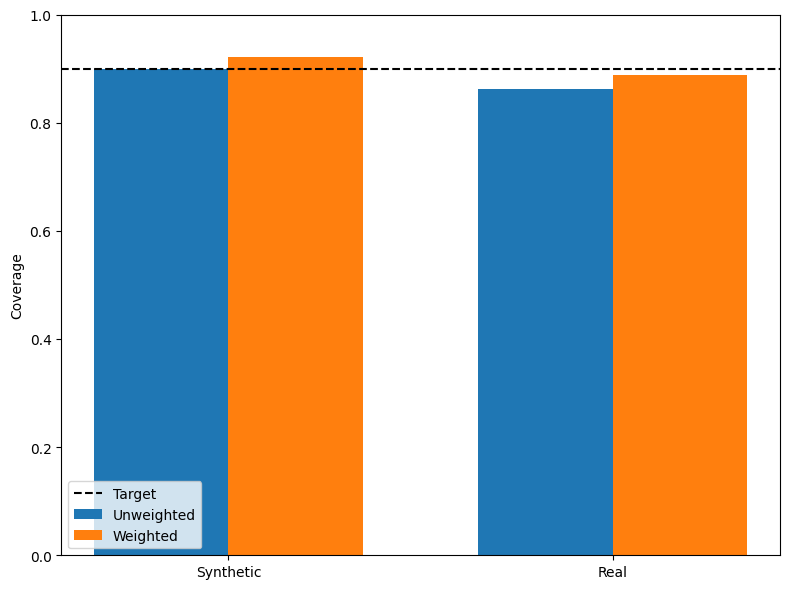

Saved figure to coverage_bar_plot.png


In [8]:
labels = ["Synthetic", "Real"]
unweighted_values = [cov_syn_unweighted, coverage_unweighted]
weighted_values   = [cov_syn_weighted,   coverage_weighted]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, unweighted_values, width, label="Unweighted")
ax.bar(x + width/2, weighted_values,   width, label="Weighted")

ax.axhline(1 - alpha, linestyle="--", color="k", label="Target")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Coverage")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("coverage_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure to coverage_bar_plot.png")

## Summary of results

Final numerical results, suitable for copying into Section 5 of the report:

In [9]:
print("=" * 60)
print("CONFORMAL PREDICTION RESULTS")
print("=" * 60)
print(f"Target coverage level (1 - alpha): {1 - alpha:.2f}")
print()
print("Quantile thresholds:")
print(f"  q_unweighted = {q_unweighted:.6f}")
print(f"  q_weighted   = {q_weighted:.6f}")
print()
print("Synthetic coverage:")
print(f"  Unweighted: {cov_syn_unweighted:.4f} ({cov_syn_unweighted*100:.2f}%)")
print(f"  Weighted:   {cov_syn_weighted:.4f}   ({cov_syn_weighted*100:.2f}%)")
print()
print("Real coverage:")
print(f"  Unweighted: {coverage_unweighted:.4f} ({coverage_unweighted*100:.2f}%)")
print(f"  Weighted:   {coverage_weighted:.4f}   ({coverage_weighted*100:.2f}%)")
print()
improvement_pp = (coverage_weighted - coverage_unweighted) * 100
print(f"Improvement on real data: {improvement_pp:+.2f} percentage points")
print("=" * 60)

CONFORMAL PREDICTION RESULTS
Target coverage level (1 - alpha): 0.90

Quantile thresholds:
  q_unweighted = 0.079215
  q_weighted   = 0.090074

Synthetic coverage:
  Unweighted: 0.9000 (90.00%)
  Weighted:   0.9219   (92.19%)

Real coverage:
  Unweighted: 0.8620 (86.20%)
  Weighted:   0.8872   (88.72%)

Improvement on real data: +2.52 percentage points
